**Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

**Load dataset**

In [3]:
iris=load_iris()

**Dataframe**

In [8]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
df=df[['petal length (cm)','petal width (cm)']]
df.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


**Visualise**

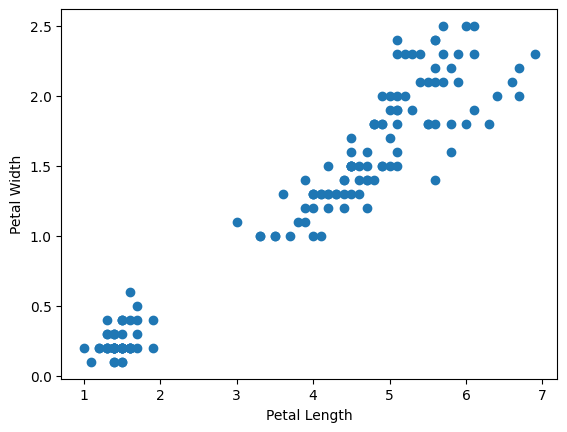

In [9]:
plt.scatter(df['petal length (cm)'],df['petal width (cm)'])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

**Scale petal length and width**

In [12]:
scaler=MinMaxScaler()
df['petal length (cm)']=scaler.fit_transform(df[['petal length (cm)']])
df['petal width (cm)']=scaler.fit_transform(df[['petal width (cm)']])

**Visualise scaled data**

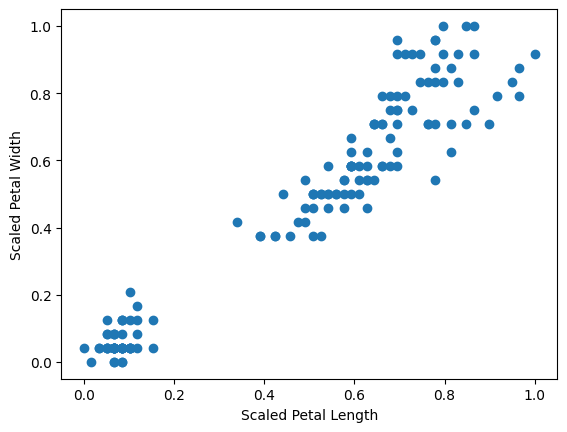

In [13]:
plt.scatter(df['petal length (cm)'],df['petal width (cm)'])
plt.xlabel("Scaled Petal Length")
plt.ylabel("Scaled Petal Width")
plt.show()

**Elbow Method**

In [16]:
sse=[]
for k in range(1,11):
    km=KMeans(n_clusters=k)
    km.fit(df)
    sse.append(km.inertia_)

**Elbow Plot**

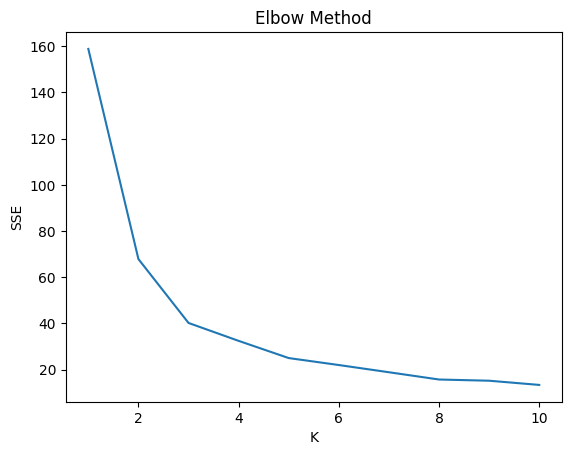

In [17]:
plt.plot(range(1,11), sse)
plt.xlabel("K")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

**Final Model**

In [19]:
km = KMeans(n_clusters=3)
y_predicted=km.fit_predict(df)

**Add cluster column to dataframe**

In [22]:
df['cluster']=y_predicted
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,5.1,3.5,0.067797,0.041667,2
1,4.9,3.0,0.067797,0.041667,2
2,4.7,3.2,0.050847,0.041667,2
3,4.6,3.1,0.084746,0.041667,2
4,5.0,3.6,0.067797,0.041667,2


**Visualise Clusters**

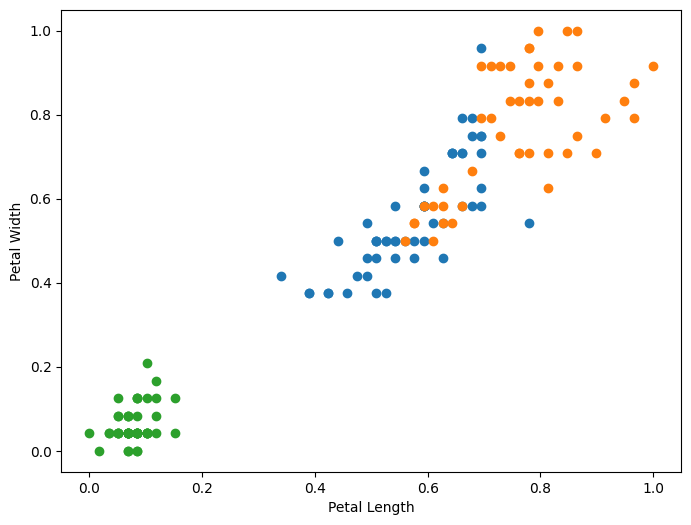

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(df[df.cluster==0]['petal length (cm)'],df[df.cluster==0]['petal width (cm)'])
plt.scatter(df[df.cluster==1]['petal length (cm)'],df[df.cluster==1]['petal width (cm)'])
plt.scatter(df[df.cluster==2]['petal length (cm)'],df[df.cluster==2]['petal width (cm)'])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

**Visualise Centroids**

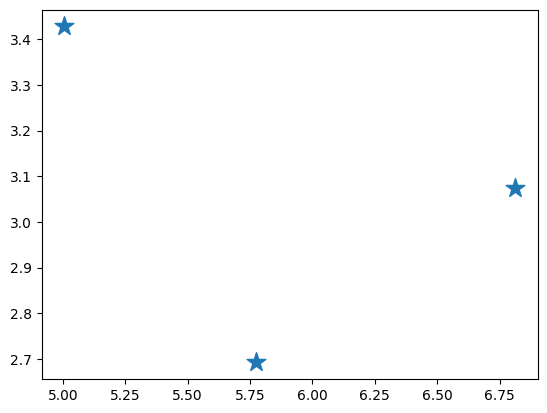

In [24]:
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],marker='*',s=200)